<a href="https://colab.research.google.com/github/HaydeePeruyero/honey-dashboard/blob/main/Dimentionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BiotrAIn 2025 Tutorial: Data integration for microbiome research using scikit-bio**


# Section 03: Dimentionality reduction (55 min)

- Time: 10:00 - 10:55:00, June 17, 2025
Welcome to the practical session 03. Created by Víctor Muñiz and Nelly Selem (Secodment host), Jeanett Daga (Secodment).

---

## Background

Microbiome studies often produce high-dimensional data, with each sample containing hundreds or thousands of microbial taxa or gene functions, typically from 16S rRNA or shotgun metagenomics. This complexity can obscure biologically relevant patterns and lead to challenges such as overfitting and noise. Dimensionality reduction techniques help simplify these datasets by projecting them into lower-dimensional spaces while retaining important variation for tasks like clustering, classification, and visualization.

Common methods include PCA and PCoA, which are linear and useful for beta diversity analysis, as well as nonlinear approaches like t-SNE and UMAP, which preserve local data structure and reveal hidden patterns in microbial communities. These tools have been widely applied in large projects such as the Human Microbiome Project (HMP) and Earth Microbiome Project [EMP]( http://www.earthmicrobiome.org, https://doi.org/10.1038/nature24621).

Choosing the right method affects biological interpretation. UMAP, for example, has gained popularity over t-SNE for better preserving both global and local relationships (https://doi.org/10.1038/nbt.4314). When combined with supervised learning or functional profiling, dimensionality reduction becomes a key step in revealing insights from increasingly complex microbiome data.

🏆 QUESTIONS
* Why is dimensionality reduction important in microbiome studies?

* How does reducing dimensions help us interpret complex biological data?

* What are the differences between PCA, PCoA, t-SNE, and UMAP?

🎯 AIMS

1. Apply dimensionality reduction techniques (PCA, PCoA, UMAP and t-SNE) to high-dimensional microbiome data for visualization and pattern recognition.

2. Explore sample clustering based on microbial profiles and metadata.


🔑 KEY POINTS

*  Microbiome data is high-dimensional; reduction aids interpretation.
*  Euclidean distance can measure many types of data sets non neccesarily from
   biological origin

*  PCA and PCoA are linear; t-SNE and UMAP are nonlinear.

*  UMAP and t-SNE capture local structure and hidden clusters.

*  EMP500 is ideal for testing dimensionality reduction.

---
📥 **Input: Multi-omic dataset from EMP500 project
  
  Sample metadata: Sample.tsv

  Metagenomic feature tables:

    ogu.biom (BIOM format for feature abundance)

📤 Output:

  PCA, PCoA, t-SNE, and UMAP plots
  Cluster patterns by metadata (e.g., geography, empo_1 empo_2)

## Preparation (5 min - 10:00 am)

Install the latest version of scikit-bio if it hasn't been (needed for every Google Colab instance).

In [125]:
from importlib.util import find_spec

In [126]:
if find_spec('skbio') is None:
    !pip install -q scikit-bio

In [127]:
!pip install -U "plotly>=6.1.1" "kaleido>=0.2.1"

In [128]:
!apt-get install -y chromium-browser

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
chromium-browser is already the newest version (1:85.0.4183.83-0ubuntu2.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [129]:
import os
os.environ["PATH"] += ":/usr/bin"

In [130]:
import skbio
skbio.__version__

'0.7.0'

We will be using different functions available in the script file ``aux_functions.py``. In order to use them, we need to load them from local drive. Please follow these instrucions:

1. Go to Drive and select `Shared with me` in your Google account.
2. Go to `Module 2 Clustering` folder and select `Organize-->Add shortcut` from the drop-down menu:
![img1](https://drive.google.com/uc?export=view&id=1lDtIl4f83JWcyS6owwow1TE0HK2KdK4c)

3. Add a shortcut for `Module 2 Clustering` to `My Drive` by selecting `All locations` tab. Choose `Add`:
![img2](https://drive.google.com/uc?export=view&id=1bXu5GUg7xLtAi0RGDJLTb2yvmbDiKotq)

4. You will now see the shortcut to `Module 2 Clustering` on your drive and can access it as a local folder:
![img2](https://drive.google.com/uc?export=view&id=1m9oQegI7N3UFNNY-7wF7wgGW1z9nO79u)

5. Run the following code to mount the folder:



In [131]:
from google.colab import drive
import os
drive.mount('/content/drive/')
# woriking directory
os.chdir('/content/drive/My Drive/cabana/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [132]:
!ls ../cabana/

4-20		  clustermap_samples.png  hclust_plot.png  images  __pycache__
aux_functions.py  data			  hclust_plot.svg  models


In [133]:
import skbio
skbio.__version__
import pandas as pd
from skbio import Table
from skbio.diversity import beta_diversity



we are using the following data to make a Beta biodiversity analysis To compute and visualize beta diversity, you need:

1. Sample metadata (latam_samples.tsv): environmental metadata per sample.
2. feature table (latam_ogu.biom)counts of microbial taxa (OGUs) per sample.
3. Phylogenetic tree (latam_ogu.nwk)for UniFrac.
4. Taxonomy Taxonomy assignment file (latam_ogu.tax). for heatmaps

## Data representation (5 min - 10:05 am)

Our data will consists on counts of microbial taxa for each sample, that we can represent as a matrix $X$ with $n$ rows (samples) and $d$ columns (taxon). First, let's create a small sample data set:

In [134]:
import pandas as pd

In [135]:
# Create the abundance table
data = {'Taxon1': [10, 2, 4, 9],'Taxon2': [5, 3, 3, 7],'Taxon3': [0, 8, 7, 3]}
samples = ['SampleA', 'SampleB', 'SampleC', 'SampleD']

df = pd.DataFrame(data, index=samples)
df

,Taxon1,Taxon2,Taxon3
SampleA,10,5,0
SampleB,2,3,8
SampleC,4,3,7
SampleD,9,7,3


In machine learning (ML) models, and particularly, non-supervised ML, our aim is to find patterns in data, for instance, how they tend to cluster together according to their similarity. For low-dimensional data, we can observe existing patterns, as we can see in the next figure for our toy dataset:

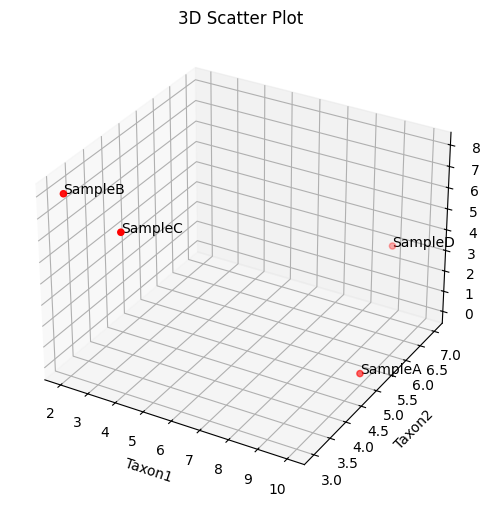

In [136]:
from aux_functions import plot_3d

plot_3d(df)

However, real datasets are **high dimensional** and **sparse**, with hundreds or thousands columns of counts. Due to the **curse of dimensionality**, and other reasons, it is very convenient to use dimensionality reduction techniques.

What we hope is that all the patterns we were able to observe in the original high-dimensional space can be recovered in the reduced space.

![img1](https://drive.google.com/uc?export=view&id=1YaKiGWovlDRI6zktIn3i7ysTpG5OtR7X)

We will explore such methods in two representations of our data: distance-based and count-based representations.


## Distances and distance matrix (10 min - 10:10 am)

A **distance** is a measure of how far apart (or *different*) two points are. There are different distance functions, as we can see in Figure 1, but in this module, we will explore the popular ones.

![Distance measure](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*BKcnB65yMzjbRAy7FQwn3w.png)
Figure 1. Distance measures.

A **distance matrix** is a simetric, positive-definite matrix were distances between pairs of points are represented according to some distance function.

### Bray Curtis distance

In the previous chapter we used the **Bray Curtis** distance without a definition. Since Euclidean distance is the most general distance, here we will learn about Bray Curtis and Euclidean distance mainly.


The Bray-Curtis distance is defined as:
$$\text{Bray-Curtis(A,B)}= \displaystyle\frac{\sum_i{∣𝑎_𝑖−𝑏_𝑖∣}}{\sum_i{(𝑎_𝑖+𝑏_𝑖)}}$$.

For our dataset, let's compute the distance manually for the first two samples:

$\sum{∣𝑎_𝑖−𝑏_𝑖∣}=|10 - 2| + |5 - 3| + |0 - 8| = 8 + 2 + 8 = 18$

$\sum{∣𝑎_𝑖+𝑏_𝑖∣}=(10 + 2) + (5 + 3) + (0 + 8) = 28$

Then, Bray-Curtis between sample A and B is $\frac{18 }{28}$ ≈ 0.6429. Now let's do it using `skbio`.

In [137]:
from scipy.spatial.distance import braycurtis

sampleA = df.loc['SampleA']
sampleB = df.loc['SampleB']

bc_distance = braycurtis(sampleA, sampleB)
print(f"Bray-Curtis Distance: {bc_distance:.4f}")

Bray-Curtis Distance: 0.6429


### Euclidean Distance
The Euclidean distance is defined as:

$$ \text{Euclidean}(A, B) = \sqrt{(a_1 - b_1)^2 + (a_2 - b_2)^2 + (a_3 - b_3)^2}$$


#### Exercise 1. Calculate manually the euclidean distance between sampple A and sample B
<details>
  <summary> Click here to see the solution</summary>


 $\text{Euclidean}(A, B) = \sqrt{(10 - 2)^2 + (5 - 3)^2 + (0 - 8)^2} = \sqrt{64 + 4 + 64} = \sqrt{132}\approx 11.4891 $

  </details>

### Distance matrices

In `python` we have different options to compute the distance matrix for all samples in our dataset. For Bray-Curtis distance, we can use `beta_diversity`from `scikit-bio`:

In [138]:
from skbio import DistanceMatrix
from skbio.diversity import beta_diversity

# Compute Bray-Curtis distance matrix
dm_bc = beta_diversity(metric='braycurtis', counts=df, ids=df.index)

print(dm_bc)

4x4 distance matrix
IDs:
'SampleA', 'SampleB', 'SampleC', 'SampleD'
Data:
[[0.         0.64285714 0.51724138 0.17647059]
 [0.64285714 0.         0.11111111 0.5       ]
 [0.51724138 0.11111111 0.         0.39393939]
 [0.17647059 0.5        0.39393939 0.        ]]


For euclidean distances, we can use `sklearn.metrics`module, which is implemented in the  `get_distance_matrix`function (from `aux_functions.py`):

In [139]:
from aux_functions import get_distance_matrix

dm_euc = get_distance_matrix(df, 'euclidean')
dm_euc

,SampleA,SampleB,SampleC,SampleD
SampleA,0.000000,11.489125,9.433981,3.741657
SampleB,11.489125,0.000000,2.236068,9.486833
SampleC,9.433981,2.236068,0.000000,7.549834
SampleD,3.741657,9.486833,7.549834,0.000000


When the number of samples $n$ is not so large, a heatmap is a good visualization of distance matrices. For illustration purposes, we will compare Bray-Curtis, Euclidean and Cosine distances:

In [140]:
dm_cos = get_distance_matrix(df, 'cosine')
dm_cos

,SampleA,SampleB,SampleC,SampleD
SampleA,1.110223e-16,6.432470e-01,0.428137,0.051696
SampleB,6.432470e-01,1.110223e-16,0.032922,0.391041
SampleC,4.281372e-01,3.292170e-02,0.000000,0.230920
SampleD,5.169595e-02,3.910414e-01,0.230920,0.000000


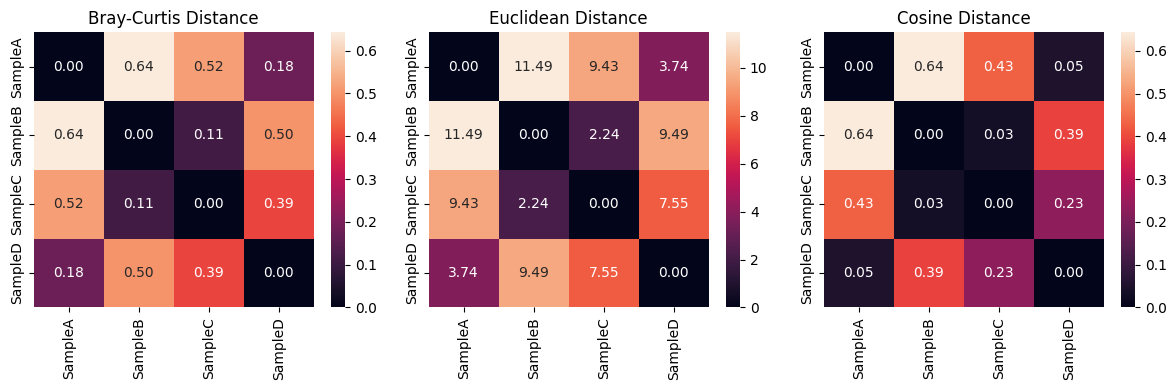

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4)) # Adjust figure size to accommodate two heatmaps

plt.subplot(1, 3, 1) # Create a subplot for the first heatmap
sns.heatmap(dm_bc.data, annot=True, fmt=".2f", xticklabels=dm_bc.ids, yticklabels=dm_bc.ids)
plt.title("Bray-Curtis Distance", fontsize=12)

plt.subplot(1, 3, 2) # Create a subplot for the second heatmap
sns.heatmap(dm_euc, annot=True, fmt=".2f", xticklabels=dm_euc.index, yticklabels=dm_euc.index)
plt.title("Euclidean Distance", fontsize=12)

plt.subplot(1, 3, 3) # Create a subplot for the second heatmap
sns.heatmap(dm_cos, annot=True, fmt=".2f", xticklabels=dm_cos.index, yticklabels=dm_cos.index)
plt.title("Cosine Distance", fontsize=12)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Load EMPO data (5 min - 10:20 am)

Now we will load EMPO data and metadata to apply dimensionality reduction techniques.

In [142]:
import skbio
from skbio import Table
from biom import load_table
from skbio.diversity import beta_diversity
#biom= Table.read(biom_path)
biom = load_table('../cabana/data/honey_Es_Shotgun_Mexico_hdf5.biom')
biom_df = biom.to_dataframe()
biom_df = biom_df.T
muestras_a_eliminar = [
    "SRR27931707", "SRR27931708", "SRR27931709",
    "SRR12632483", "SRR12632493"
]
biom_df = biom_df.drop(index=muestras_a_eliminar, errors='ignore')
biom_df

,3888,3911,3880,57577,3827,34305,3913,3917,3914,157791,...,2843777,1982112,1929964,1856642,1972568,2507503,1923406,1923598,3059727,2560285
SRR27931704,73794.0,55550.0,22797.0,19245.0,31136.0,69228.0,5313.0,30642.0,25735.0,23520.0,...,0,0,0,0,0,0,0,0,0,0
SRR27931705,29239.0,24617.0,10918.0,7898.0,13701.0,66748.0,2263.0,11649.0,9504.0,9138.0,...,0,0,0,0,0,0,0,0,0,0
SRR27931706,44589.0,37483.0,16439.0,12171.0,17985.0,160618.0,3350.0,16749.0,13164.0,12849.0,...,0,0,0,0,0,0,0,0,0,0
SRR27931710,683.0,582.0,277.0,593.0,428.0,973.0,56.0,296.0,228.0,191.0,...,0,0,0,0,0,0,0,0,0,0
SRR27931711,1849.0,1687.0,907.0,2578.0,866.0,1104.0,99.0,988.0,592.0,723.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89_Scapto,42397.0,22699.0,10819.0,13289.0,24138.0,11807.0,2568.0,20230.0,15409.0,11838.0,...,0,0,0,0,0,0,0,0,0,0
90_Scapto,56250.0,24967.0,13609.0,12887.0,20627.0,14294.0,1874.0,16111.0,9005.0,9109.0,...,0,0,0,0,0,0,0,0,0,0
91_Scapto,45798.0,25574.0,11639.0,10340.0,21284.0,11970.0,2000.0,21006.0,11017.0,9479.0,...,0,0,0,0,0,0,0,0,0,0
92_Scapto,24452.0,15487.0,7215.0,4644.0,10751.0,5718.0,1033.0,7634.0,5593.0,5856.0,...,0,0,0,0,0,0,0,0,0,0


In [143]:
# metadata
# Read the TSV file directly from the URL into a pandas DataFrame
metadata_df = pd.read_csv('../cabana/data/metadata_Es_Shotgun_Mex_ordenado.csv', low_memory=False, index_col='sample_name')
valid_sample_names = biom_df.index.intersection(metadata_df.index)
valid_metadata_df = metadata_df.loc[valid_sample_names]
valid_metadata_df

,Assey_Type,AvgSpotLen,Bases,BioProject,BioSample,Size,Colection_Date,Consent,Experiment,ScientificName,...,Longitud,Model,LibraryName,LibrarySource,SRAStudy,Platform,ID,LibraryLayout,CenterName,Notas
SRR27931704,WGS,302,5697274998,PRJNA1074714,SAMN39880875,2036066464,18/10/2021,public,SRX23588786,honey,...,-3.599193,Illumina NovaSeq 6000,10,METAGENOMIC,SRP489180,ILLUMINA,H19,PAIRED,DAIRY RESEARCH INSTITUTE OF ASTURIAS- SPANISH ...,NaN
SRR27931705,WGS,302,4395825628,PRJNA1074714,SAMN39880874,1561536444,18/10/2021,public,SRX23588785,honey,...,-3.599193,Illumina NovaSeq 6000,9,METAGENOMIC,SRP489180,ILLUMINA,H18,PAIRED,DAIRY RESEARCH INSTITUTE OF ASTURIAS- SPANISH ...,NaN
SRR27931706,WGS,302,4966203364,PRJNA1074714,SAMN39880873,1773897028,18/10/2021,public,SRX23588784,honey,...,-3.599193,Illumina NovaSeq 6000,8,METAGENOMIC,SRP489180,ILLUMINA,H17,PAIRED,DAIRY RESEARCH INSTITUTE OF ASTURIAS- SPANISH ...,NaN
SRR27931710,WGS,302,696696786,PRJNA1074714,SAMN39880928,243693766,18/10/2021,public,SRX23588780,honey,...,-5.968321,Illumina NovaSeq 6000,63,METAGENOMIC,SRP489180,ILLUMINA,H78,PAIRED,DAIRY RESEARCH INSTITUTE OF ASTURIAS- SPANISH ...,NaN
SRR27931711,WGS,302,1026133486,PRJNA1074714,SAMN39880927,345978931,18/10/2021,public,SRX23588779,honey,...,-5.968321,Illumina NovaSeq 6000,62,METAGENOMIC,SRP489180,ILLUMINA,H77,PAIRED,DAIRY RESEARCH INSTITUTE OF ASTURIAS- SPANISH ...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89_Scapto,WGS,not provided,10.795.256.666,PRJNA1235305,SAMN47325583,not provided,09/05/2022,non-public,not provided,honey metagenome,...,97.242417,Illumina NovaSeq 6000,not provided,METAGENOMIC,SRP569975,ILLUMINA,SRR32671093,PAIRED,not provided,NaN
90_Scapto,WGS,not provided,11.146.031.478,PRJNA1235305,SAMN47325585,not provided,09/05/2022,non-public,not provided,honey metagenome,...,97.242417,Illumina NovaSeq 6000,not provided,METAGENOMIC,SRP569975,ILLUMINA,SRR32671091,PAIRED,not provided,NaN
91_Scapto,WGS,not provided,11.330.001.422,PRJNA1235305,SAMN47325584,not provided,09/05/2022,non-public,not provided,honey metagenome,...,97.242417,Illumina NovaSeq 6000,not provided,METAGENOMIC,SRP569975,ILLUMINA,SRR32671092,PAIRED,not provided,NaN
92_Scapto,WGS,not provided,11.330.001.422,PRJNA1235305,SAMN47325586,not provided,11/05/2022,non-public,not provided,honey metagenome,...,96.936694,Illumina NovaSeq 6000,not provided,METAGENOMIC,SRP569975,ILLUMINA,SRR32671090,PAIRED,not provided,NaN


In [144]:
labels_data = valid_metadata_df['Specie']
labels_data

,Specie
SRR27931704,Spanish PDO
SRR27931705,Spanish PDO
SRR27931706,Spanish PDO
SRR27931710,Spanish PDO
SRR27931711,Spanish PDO
...,...
89_Scapto,Scaptotrigona mexicana
90_Scapto,Scaptotrigona mexicana
91_Scapto,Scaptotrigona mexicana
92_Scapto,Scaptotrigona mexicana


Dimensionality reduction can be applied to different representations of data, best method depends on the characteristics of such representation. We will explore some reduction techniques for count-based and distance-based representations.

## Frecuency-based representation (15 min - 10:25 am)

We have two weighting schemes for gene occurrence: frecuency (`biom_df`) and inverse-frecuency (`biom_tfidf`).

In [145]:
from aux_functions import get_tfidf

tfidf_vect, tfidf = get_tfidf(biom_df)
biom_tfidf = pd.DataFrame(tfidf,columns=tfidf_vect.get_feature_names_out(),index=biom_df.index)
biom_tfidf

,3888,3911,3880,57577,3827,34305,3913,3917,3914,157791,...,2843777,1982112,1929964,1856642,1972568,2507503,1923406,1923598,3059727,2560285
SRR27931704,0.044146,0.033232,0.013638,0.011513,0.018626,0.041414,0.003202,0.018331,0.015395,0.014070,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SRR27931705,0.010947,0.009217,0.004088,0.002957,0.005130,0.024991,0.000854,0.004361,0.003558,0.003421,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SRR27931706,0.024316,0.020441,0.008965,0.006637,0.009808,0.087592,0.001841,0.009134,0.007179,0.007007,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SRR27931710,0.002853,0.002431,0.001157,0.002477,0.001788,0.004065,0.000236,0.001237,0.000953,0.000798,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SRR27931711,0.002934,0.002677,0.001439,0.004091,0.001374,0.001752,0.000158,0.001568,0.000939,0.001147,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89_Scapto,0.035908,0.019225,0.009163,0.011255,0.020444,0.010000,0.002191,0.017134,0.013051,0.010026,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
90_Scapto,0.053660,0.023818,0.012982,0.012294,0.019677,0.013636,0.001801,0.015369,0.008590,0.008690,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
91_Scapto,0.042243,0.023589,0.010735,0.009537,0.019632,0.011041,0.001859,0.019375,0.010162,0.008743,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
92_Scapto,0.009685,0.006134,0.002858,0.001839,0.004258,0.002265,0.000412,0.003024,0.002215,0.002319,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Factorization methods

Our data matrix (frequency of inverse-frequency) is high-dimensional, sparse and non-negative. There are two methods for dimensionality reduction based on matrix factorizations that are appropriate for the characteristics of the data.

#### Truncated SVD factorization

SVD is a matrix factorization technique that factors a matrix $A$ into the three matrices U, Σ, and V. **Truncated SVD** produces a factorization where the **number of columns is equal to the specified truncation**.

![](https://drive.google.com/uc?export=view&id=1UsZNvN1hxr1TLjbcfLk5kfxRqWDiNUtM)


In [146]:
from aux_functions import get_lsa, get_nmf

dir_fact = '../cabana/models/'
n_comp = 50
exfact = False
nf = 'svd_tfidf'
fact_svd = get_lsa(biom_tfidf, exist_fact = exfact, fact_path = dir_fact, n_file = nf, n_comp = n_comp, save=True)

In [147]:
import plotly.express as px

embedding = fact_svd
embedding

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
SRR27931704,0.672773,-0.174884,0.120038,-0.041224,0.446065,0.463080,-0.041136,0.052625,-0.047810,-0.083311,...,-0.004492,-0.002639,0.002230,-0.000588,-0.016806,0.004961,0.002246,-0.005601,-0.004239,-0.002665
SRR27931705,0.895717,-0.400466,0.024303,-0.116061,0.041798,0.061165,-0.052865,-0.039672,0.002175,-0.033199,...,0.002129,0.002460,-0.002668,0.001614,0.004052,-0.003444,0.002308,-0.000613,-0.003059,-0.000687
SRR27931706,0.866293,-0.252166,0.064959,-0.082336,0.235011,0.243589,-0.051346,-0.083759,-0.090570,0.107225,...,0.009904,0.005797,0.002984,0.004463,0.005727,-0.000301,-0.003379,-0.000526,0.003871,0.002738
SRR27931710,0.842673,-0.294450,-0.122498,0.363822,-0.040909,-0.015536,0.187409,0.049041,0.002274,-0.025203,...,-0.002759,0.003794,0.001258,0.000961,0.001970,-0.003899,0.001328,-0.000193,0.000090,-0.006988
SRR27931711,0.631726,0.735021,-0.044872,0.028443,0.067046,0.077080,0.113861,-0.038447,0.172417,0.020896,...,0.006383,0.000027,-0.001419,-0.006969,-0.001037,0.001731,-0.001959,-0.001964,-0.004158,-0.012882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89_Scapto,0.349301,-0.139411,0.767112,0.151006,0.325228,-0.347983,-0.002004,-0.026457,0.015650,-0.019277,...,-0.000610,-0.001877,0.000492,-0.000216,0.000274,-0.001432,-0.001343,-0.003994,-0.000594,-0.006702
90_Scapto,0.231581,-0.086946,0.695070,0.155391,0.454565,-0.362763,0.009577,-0.020727,0.002920,-0.007679,...,0.001304,0.000843,0.000033,0.000062,0.000166,0.000274,0.000158,0.001427,-0.000190,0.001599
91_Scapto,0.247039,-0.090394,0.755215,0.161826,0.372417,-0.381011,0.008718,-0.028367,0.013269,-0.009711,...,-0.001836,0.000625,-0.001077,0.000107,-0.000663,0.000774,0.000186,-0.000214,0.001867,0.000842
92_Scapto,0.102178,-0.014434,0.412353,0.095725,0.305296,-0.365053,-0.006805,0.062583,0.022980,0.010597,...,-0.001730,0.001486,-0.000353,0.001167,0.000207,0.000469,-0.000845,-0.001137,-0.000585,-0.000465


In [148]:
reduced_proj = pd.DataFrame({'x1': embedding.iloc[:,0], 'x2': embedding.iloc[:,1], 'label': labels_data})
fig = px.scatter(reduced_proj, x='x1', y='x2', color = 'label', title='Reduced SVD plot')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

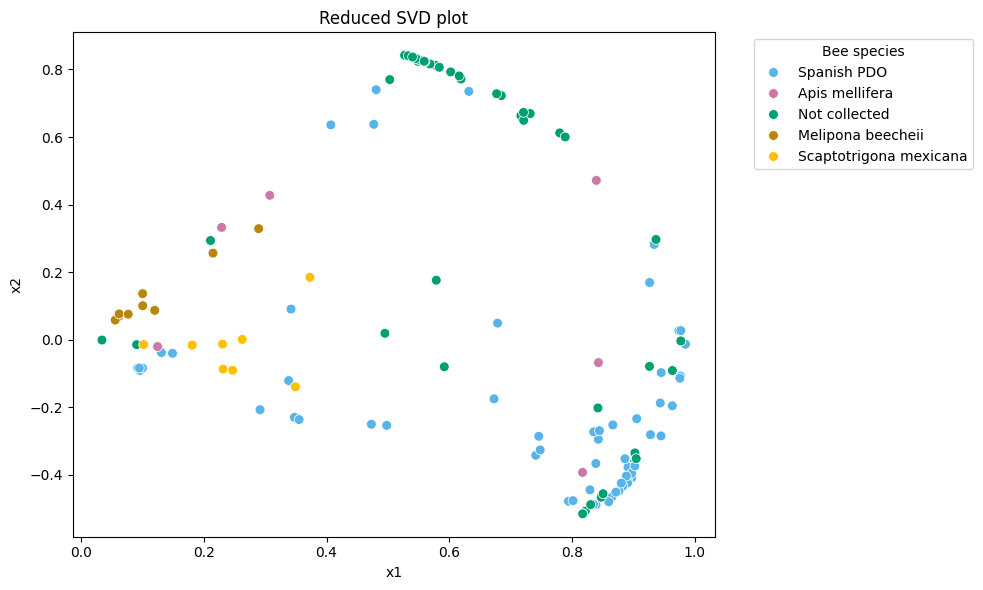

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el DataFrame como antes
reduced_proj = pd.DataFrame({
    'x1': embedding.iloc[:, 0],
    'x2': embedding.iloc[:, 1],
    'label': labels_data
})

# Definir paleta fija de 5 colores para especies específicas
palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",     # naranja
    "Spanish PDO": "#56B4E9",        # azul claro
    "Not collected": "#009E73"       # verde azulado — ¡sin espacio!
}


# Crear el scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=reduced_proj, x='x1', y='x2', hue='label', palette=palette, s=50)

# Estilo del plot
plt.title("Reduced SVD plot")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="Bee species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Guardar como PNG y SVG en alta calidad
plt.savefig("../cabana/images/reduced_plot.png", dpi=300)
plt.savefig("../cabana/images/reduced_plot.svg", format="svg")

# Mostrar el gráfico
plt.show()


#### Non-negative matrix factorization (NMF).

[NMF](https://en.wikipedia.org/wiki/Non-negative_matrix_factorization) is a group of algorithms in multivariate analysis and linear algebra where a matrix V is factorized into (usually) two matrices W and H, with the property that all three matrices **have no negative elements**.

![](https://drive.google.com/uc?export=view&id=1CjkAK6MFYTWXigpg6Nk1KPrDE3hS4yHe)


In [150]:
dir_fact = '../cabana/models/'
n_comp = 50
exfact = False
nf = 'nmf_tfidf'
fact_nmf = get_nmf(biom_tfidf, exist_fact = exfact, fact_path = dir_fact, n_file = nf, n_comp = n_comp, save=True)

In [151]:
embedding = fact_nmf
reduced_proj = pd.DataFrame({'x1': embedding.iloc[:,0], 'x2': embedding.iloc[:,1], 'label': labels_data})
fig = px.scatter(reduced_proj, x='x1', y='x2', color = 'label', title='Reduced NMF plot')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

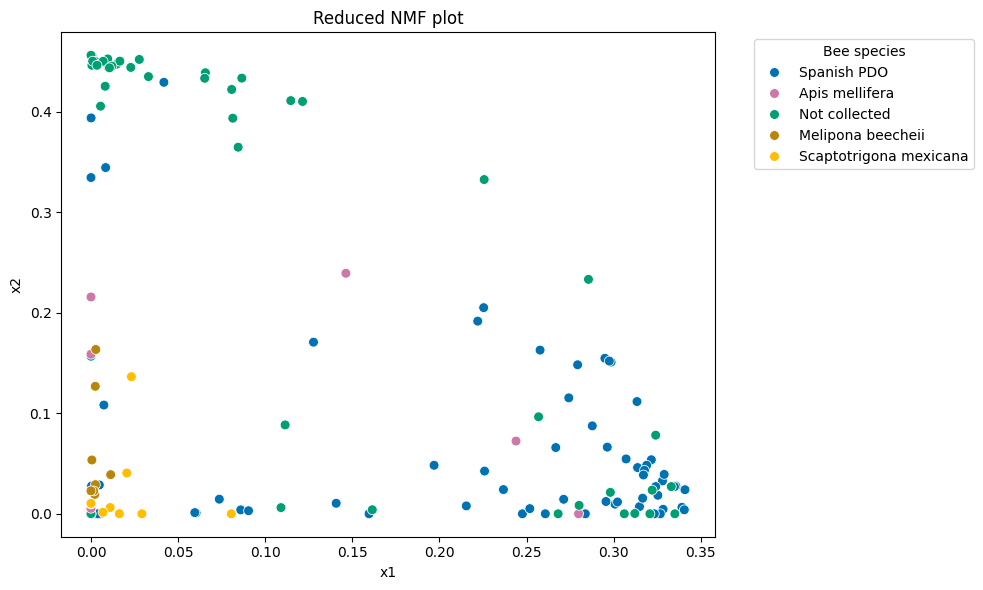

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear DataFrame
embedding = fact_nmf
reduced_proj = pd.DataFrame({
    'x1': embedding.iloc[:, 0],
    'x2': embedding.iloc[:, 1],
    'label': labels_data
})

# Colores personalizados y fijos para 5 especies
palette = {
    "Melipona beecheii": "#b8860b",         # miel
    "Scaptotrigona mexicana": "#FFBF00",    # amarillo
    "Apis mellifera": "#CC79A7",            # púrpura suave
    "Spanish PDO": "#0072B2",               # azul oscuro
    "Not collected": "#009E73"              # verde azulado
}

# Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(data=reduced_proj, x='x1', y='x2', hue='label', palette=palette, s=50)

plt.title("Reduced NMF plot")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="Bee species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Guardar como PNG y SVG
plt.savefig("../cabana/images/reduced_nmf_plot.png", dpi=300)
plt.savefig("../cabana/images/reduced_nmf_plot.svg", format='svg')
plt.show()



### Manifold learning methods

[Manifold learning](https://scikit-learn.org/stable/modules/manifold.html) is an approach to non-linear dimensionality reduction. Algorithms for this task are based on the idea that the dimensionality of many data sets is only artificially high.

There are two main approaches for manifold learning:
- t-stochastic neighbor embedding ([t-SNE](https://lvdmaaten.github.io/tsne/)). Good at preserving **local structures** in data.
![](https://drive.google.com/uc?export=view&id=1ItFWBf0E66ZiurWf3yp3JPzSUcTAfzkg)

- Uniform Manifold Approximation and Prediction ([UMAP](https://umap-learn.readthedocs.io/en/latest/index.html)).
![](https://drive.google.com/uc?export=view&id=1IAsUo3FCcZ3kb_3IZYJz3DVRZZ_RjqqJ)

  - better preserves both local and global structure
  - supports *predict* methods, allowing new data to be projected into an existing embedding


Here, we will be using UMAP.

In [153]:
import umap.umap_ as umap

reducer = umap.UMAP(n_neighbors=5, n_components=3, min_dist=.12, metric='braycurtis', random_state=42)
embedding = reducer.fit_transform(biom_tfidf)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [154]:
reduced_proj = pd.DataFrame({'x1': embedding[:,0], 'x2': embedding[:,1], 'label': labels_data})
#reduced_proj['clust'].astype('category')
fig = px.scatter(reduced_proj, x='x1', y='x2', color = 'label', title='UMAP')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

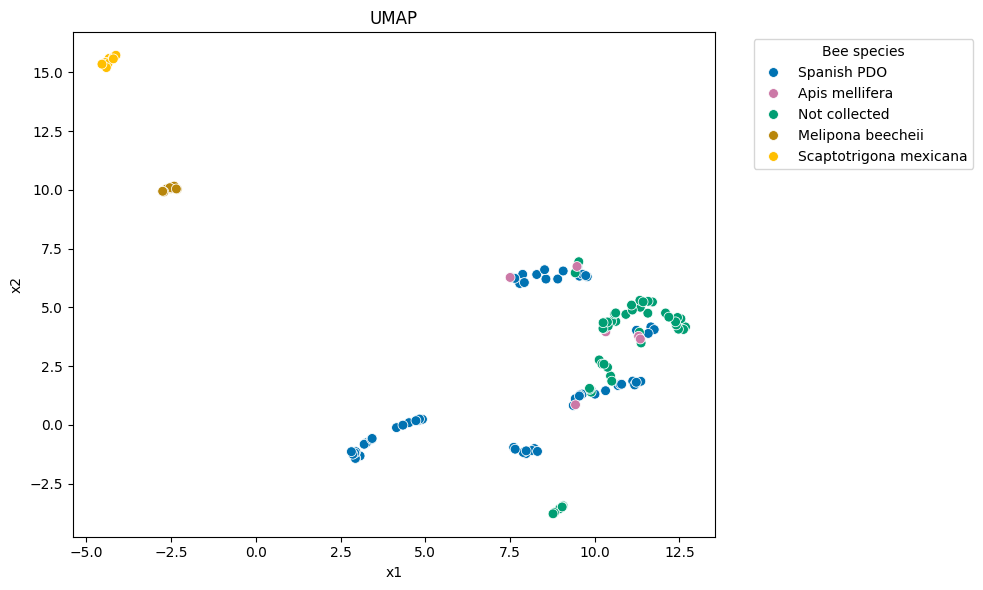

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el DataFrame desde array embedding (no iloc)
reduced_proj = pd.DataFrame({
    'x1': embedding[:, 0],
    'x2': embedding[:, 1],
    'label': labels_data
})

# Paleta personalizada fija
palette = {
    "Melipona beecheii": "#b8860b",         # miel
    "Scaptotrigona mexicana": "#FFBF00",    # amarillo
    "Apis mellifera": "#CC79A7",            # púrpura suave
    "Spanish PDO": "#0072B2",               # azul oscuro
    "Not collected": "#009E73"              # verde azulado
}

# Crear el scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=reduced_proj, x='x1', y='x2', hue='label', palette=palette, s=50)

plt.title("UMAP")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="Bee species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Guardar como imagen PNG y SVG
plt.savefig("../cabana/images/umap_plot.png", dpi=300)
plt.savefig("../cabana/images/umap_plot.svg", format="svg")

# Mostrar el gráfico
plt.show()


#### Exercise 2. Change the parameters of UMAP to obtain different data configurations. Check if you can observe interesting patterns


## Distance-based representations (10 min - 10:40 am)

First, we will create a distance matrix for biom data:

In [156]:
# Calculate Bray-Curtis distances
#biom_dm = beta_diversity("braycurtis", biom_df)
biom_dm = beta_diversity("braycurtis", biom_tfidf)

# Convert the distance matrix to a pandas DataFrame
biom_dm = biom_dm.to_data_frame()
biom_dm.index = biom_df.index
biom_dm

,SRR27931704,SRR27931705,SRR27931706,SRR27931710,SRR27931711,SRR27931712,SRR27931713,SRR27931714,SRR27931715,SRR27931716,...,43_Scapto,45_Melli,46_Melli,47_Melli,51_Scapto,89_Scapto,90_Scapto,91_Scapto,92_Scapto,93_Scapto
SRR27931704,0.000000,0.472839,0.327473,0.650924,0.745702,0.633359,0.466538,0.634039,0.787718,0.657046,...,0.677918,0.870091,0.845697,0.788105,0.666604,0.654034,0.682806,0.692053,0.829209,0.741750
SRR27931705,0.472839,0.000000,0.267989,0.472542,0.700900,0.370324,0.231957,0.341332,0.736852,0.568557,...,0.808773,0.838556,0.820326,0.763624,0.799662,0.782942,0.820834,0.819295,0.816505,0.785612
SRR27931706,0.327473,0.267989,0.000000,0.522097,0.718024,0.478716,0.247931,0.474125,0.733014,0.594357,...,0.745435,0.859335,0.833777,0.773499,0.721197,0.718687,0.758405,0.757006,0.808868,0.725332
SRR27931710,0.650924,0.472542,0.522097,0.000000,0.684557,0.280734,0.539580,0.292889,0.382720,0.255779,...,0.860048,0.873751,0.854745,0.830654,0.840882,0.838585,0.876177,0.870779,0.843443,0.830914
SRR27931711,0.745702,0.700900,0.718024,0.684557,0.000000,0.581398,0.763797,0.624643,0.674352,0.590844,...,0.897282,0.854314,0.846946,0.833522,0.851229,0.897073,0.907513,0.903499,0.886418,0.877038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89_Scapto,0.654034,0.782942,0.718687,0.838585,0.897073,0.865424,0.747448,0.868933,0.879123,0.823736,...,0.177048,0.801939,0.742555,0.621991,0.123095,0.000000,0.169409,0.132732,0.566650,0.321409
90_Scapto,0.682806,0.820834,0.758405,0.876177,0.907513,0.901319,0.780525,0.904589,0.893278,0.857394,...,0.264005,0.841074,0.782305,0.670980,0.139559,0.169409,0.000000,0.102984,0.609361,0.387523
91_Scapto,0.692053,0.819295,0.757006,0.870779,0.903499,0.891434,0.779564,0.895005,0.895747,0.854239,...,0.237702,0.820062,0.763980,0.648002,0.107306,0.132732,0.102984,0.000000,0.602163,0.368368
92_Scapto,0.829209,0.816505,0.808868,0.843443,0.886418,0.881785,0.790188,0.883602,0.834162,0.832466,...,0.542449,0.768338,0.672710,0.524284,0.592398,0.566650,0.609361,0.602163,0.000000,0.326907


For dimension reduction, we will use two popular approaches for distance matrix: Principal Component Analysis (PCA) and non-metric Multidimensional Scaling (MDS)

#### Principal component analysis (PCA) and principal coordinate analysis (PCoA).

PCA and PCoA are very similar. They performs dimensionality reduction by projecting the original data into ortogonal coordinates (principal components), defining a new coordinate system.

The solutions of both, PCA and PCoA are based on eigendecomposition of

$$
  B = U \Lambda U',
$$
for some matrix square matrix $B$.
- In PCA $B=X'X$, i.e., the sample covariance of data based on the orignal attributes $X$. Note that, if data are standardized, covariance is equivalent to euclidean distance.
- In PCoA, $B$ is **a distance** matrix, allowing for different distance functions, including Bray-Curtis and other non-euclidean distances.

In [157]:
from skbio.stats.ordination import pcoa
embedding = pcoa(biom_dm, number_of_dimensions=3).samples

reduced_proj = pd.DataFrame({'x1': embedding['PC1'], 'x2': embedding['PC2']})
reduced_proj.index = biom_dm.index
reduced_proj['label'] = labels_data
fig = px.scatter(reduced_proj, x='x1', y='x2', color = 'label', title='PCoA')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

/usr/local/lib/python3.11/dist-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:258: RuntimeWarning:

The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.43486315989841245 whereas the largest positive one is 11.460814948442962.



/usr/local/lib/python3.11/dist-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:258: RuntimeWarning:

The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.43486315989841245 whereas the largest positive one is 11.460814948442962.



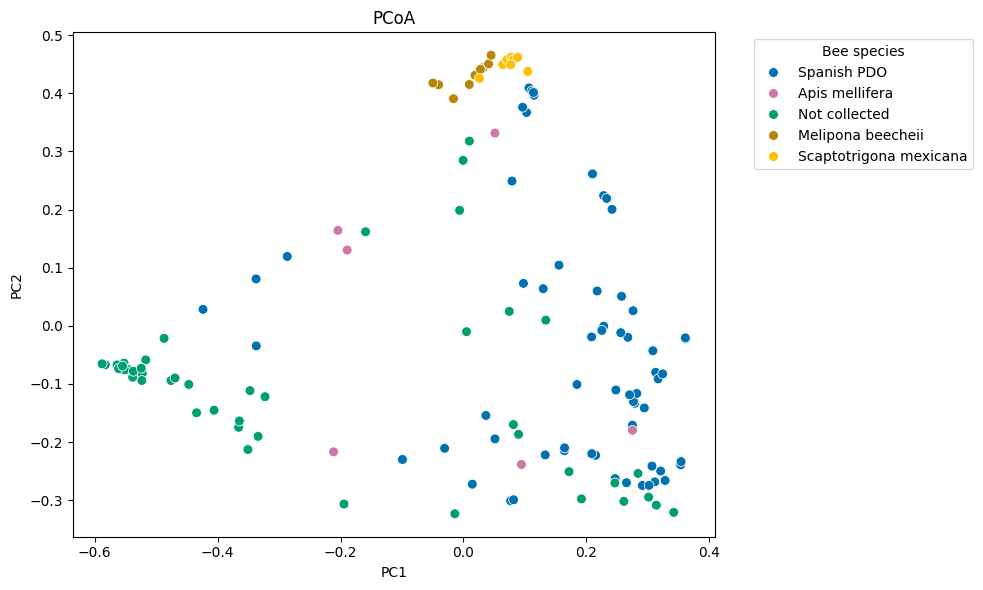

In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skbio.stats.ordination import pcoa

# Calcular embedding de PCoA
embedding = pcoa(biom_dm, number_of_dimensions=3).samples
embedding.index = biom_dm.index

# Crear DataFrame con PC1 y PC2
reduced_proj = pd.DataFrame({
    'x1': embedding['PC1'],
    'x2': embedding['PC2']
}, index=biom_dm.index)

# Agregar las etiquetas
reduced_proj['label'] = labels_data

# Eliminar filas con datos faltantes
reduced_proj = reduced_proj.dropna(subset=["x1", "x2", "label"])
reduced_proj['label'] = reduced_proj['label'].astype(str)

# Paleta de colores personalizada
palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

# Crear scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=reduced_proj, x='x1', y='x2', hue='label', palette=palette, s=50)

plt.title("PCoA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Bee species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Guardar como PNG y SVG
plt.savefig("../cabana/images/pcoa_plot.png", dpi=300)
plt.savefig("../cabana/images/pcoa_plot.svg", format="svg")
plt.show()


In [159]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(biom_dm)

pca = PCA(n_components=3)
#embedding = pca.fit_transform(scaled_data)
embedding = pca.fit_transform(biom_dm)

reduced_proj = pd.DataFrame({'x1': embedding[:,0], 'x2': embedding[:,1], 'label': labels_data})
fig = px.scatter(reduced_proj, x='x1', y='x2', color = 'label', title='PCA')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

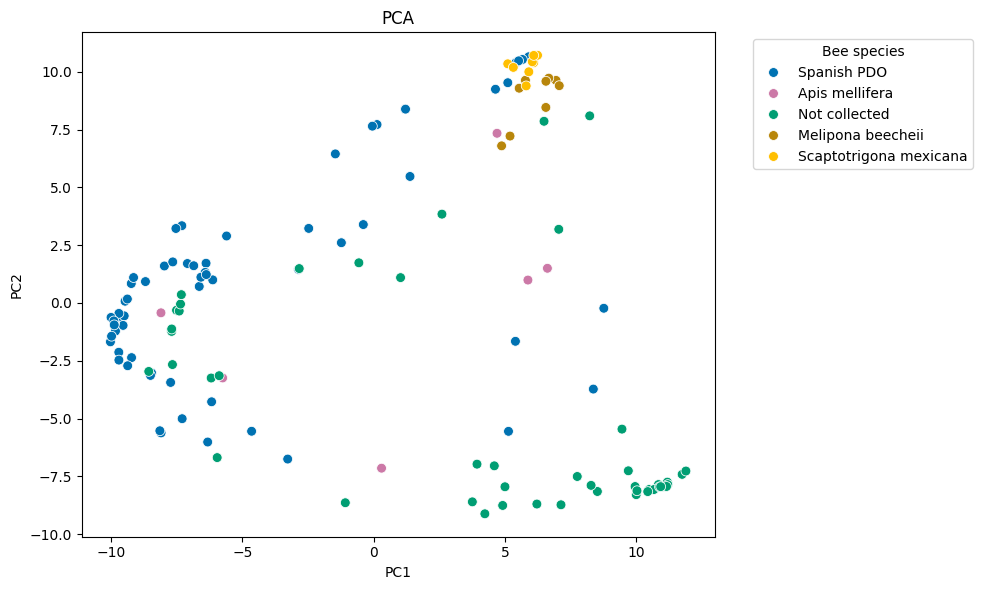

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Escalar los datos
scaler = StandardScaler()
scaled_data = scaler.fit_transform(biom_dm)

# Aplicar PCA
pca = PCA(n_components=3)
embedding = pca.fit_transform(scaled_data)

# Crear DataFrame con resultados y etiquetas
reduced_proj = pd.DataFrame({
    'x1': embedding[:, 0],
    'x2': embedding[:, 1],
    'label': labels_data
}, index=biom_dm.index)

# Limpiar datos faltantes
reduced_proj = reduced_proj.dropna(subset=["x1", "x2", "label"])
reduced_proj['label'] = reduced_proj['label'].astype(str)

# Paleta de colores fija
palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

# Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(data=reduced_proj, x='x1', y='x2', hue='label', palette=palette, s=50)

plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Bee species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Guardar
plt.savefig("../cabana/images/pca_plot.png", dpi=300)
plt.savefig("../cabana/images/pca_plot.svg", format="svg")
plt.show()


#### Non-metric MDS

MDS takes a distance matrix (pairwise dissimilarities) as input and maps the objects to coordinates such that the distances in the new space approximate the original dissimilarities as closely as possible.

We can use
- **classical MDS** if the input is Euclidean distances, it uses eigenvalue decomposition to find the optimal configuration analytically. In this case, MDS=PCA.

- **Non-Metric MDS**: Used when only the rank order of dissimilarities matters, not their exact values.

In [161]:
from sklearn.manifold import MDS

#biom_dm = np.round(biom_dm,5)
nmds = MDS(n_components=2, dissimilarity='precomputed', metric=False, random_state=42)
embedding = nmds.fit_transform(biom_dm)

In [162]:
reduced_proj = pd.DataFrame({'x1': embedding[:,0], 'x2': embedding[:,1], 'label': labels_data})
fig = px.scatter(reduced_proj, x='x1', y='x2', color = 'label', title='non-metric MDS')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

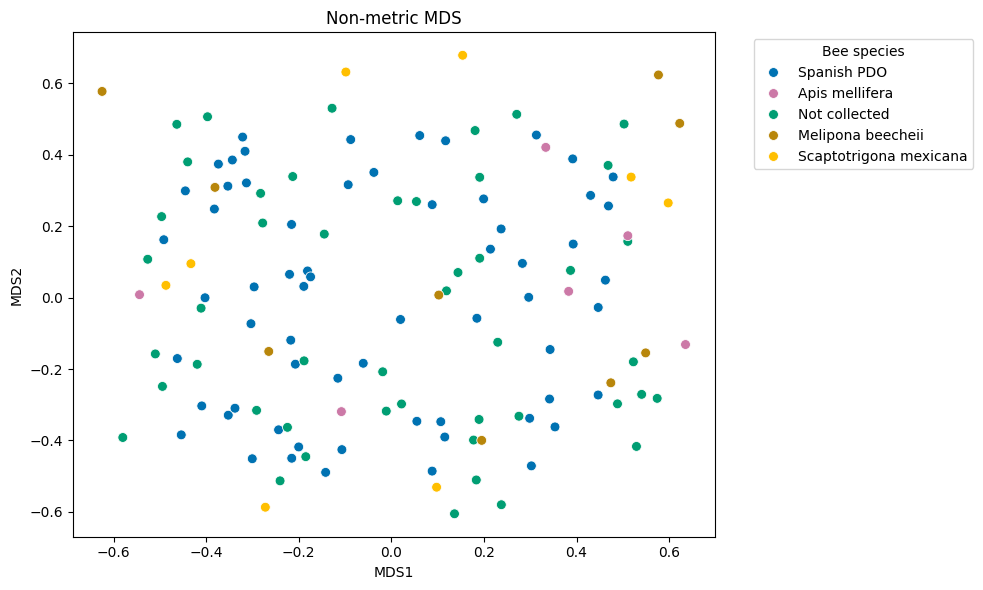

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el DataFrame con el resultado de MDS
reduced_proj = pd.DataFrame({
    'x1': embedding[:, 0],
    'x2': embedding[:, 1],
    'label': labels_data
})

# Eliminar posibles datos faltantes
reduced_proj = reduced_proj.dropna(subset=["x1", "x2", "label"])
reduced_proj['label'] = reduced_proj['label'].astype(str)

# Paleta de colores personalizada
palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

# Crear scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=reduced_proj, x='x1', y='x2', hue='label', palette=palette, s=50)

plt.title("Non-metric MDS")
plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.legend(title="Bee species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Guardar como PNG y SVG
plt.savefig("../cabana/images/nmds_plot.png", dpi=300)
plt.savefig("../cabana/images/nmds_plot.svg", format="svg")
plt.show()


In [164]:
biom_dm = beta_diversity("braycurtis", biom_df)
#biom_dm = beta_diversity("braycurtis", biom_tfidf)

# Convert the distance matrix to a pandas DataFrame
biom_dm = biom_dm.to_data_frame()
biom_dm.index = biom_df.index
biom_dm

,SRR27931704,SRR27931705,SRR27931706,SRR27931710,SRR27931711,SRR27931712,SRR27931713,SRR27931714,SRR27931715,SRR27931716,...,43_Scapto,45_Melli,46_Melli,47_Melli,51_Scapto,89_Scapto,90_Scapto,91_Scapto,92_Scapto,93_Scapto
SRR27931704,0.000000,0.436158,0.317558,0.867663,0.813419,0.748100,0.455968,0.659974,0.769909,0.651757,...,0.653048,0.788900,0.795742,0.749409,0.652130,0.655934,0.666661,0.690396,0.811893,0.743578
SRR27931705,0.436158,0.000000,0.229351,0.864936,0.801539,0.574462,0.248735,0.360682,0.734562,0.608850,...,0.753991,0.794029,0.800467,0.756696,0.721326,0.729543,0.757733,0.759129,0.811086,0.747602
SRR27931706,0.317558,0.229351,0.000000,0.863177,0.787890,0.656934,0.244550,0.492034,0.717624,0.597222,...,0.700678,0.786098,0.791568,0.744257,0.668439,0.678394,0.710343,0.715527,0.795820,0.725272
SRR27931710,0.867663,0.864936,0.863177,0.000000,0.665232,0.939767,0.847492,0.808426,0.840339,0.777563,...,0.928539,0.942642,0.934801,0.920232,0.919697,0.917707,0.922282,0.920150,0.932129,0.909770
SRR27931711,0.813419,0.801539,0.787890,0.665232,0.000000,0.881680,0.859130,0.680060,0.780084,0.690645,...,0.929867,0.881559,0.879721,0.875484,0.876156,0.931122,0.934099,0.932240,0.939604,0.915616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89_Scapto,0.655934,0.729543,0.678394,0.917707,0.931122,0.844802,0.697822,0.844299,0.847780,0.810276,...,0.182652,0.651373,0.603417,0.500981,0.118606,0.000000,0.154462,0.120124,0.435592,0.276996
90_Scapto,0.666661,0.757733,0.710343,0.922282,0.934099,0.866697,0.719087,0.878459,0.852784,0.833745,...,0.268940,0.676116,0.627551,0.541825,0.142274,0.154462,0.000000,0.106312,0.461298,0.311953
91_Scapto,0.690396,0.759129,0.715527,0.920150,0.932240,0.866305,0.723102,0.867684,0.861818,0.837736,...,0.236606,0.661190,0.614747,0.526600,0.101622,0.120124,0.106312,0.000000,0.454054,0.297662
92_Scapto,0.811893,0.811086,0.795820,0.932129,0.939604,0.852910,0.785421,0.881641,0.832023,0.845971,...,0.433758,0.686027,0.625052,0.517146,0.453658,0.435592,0.461298,0.454054,0.000000,0.238551


In [165]:
from sklearn.manifold import MDS

#biom_dm = np.round(biom_dm,5)
nmds = MDS(n_components=2, dissimilarity='precomputed', metric=False, random_state=42)
embedding = nmds.fit_transform(biom_dm)

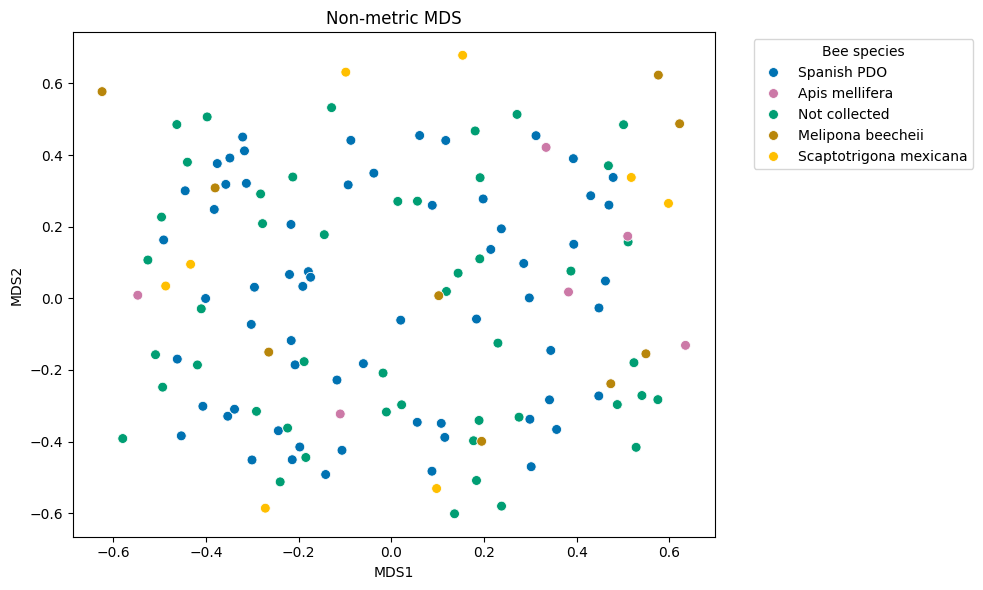

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el DataFrame con el resultado de MDS
reduced_proj = pd.DataFrame({
    'x1': embedding[:, 0],
    'x2': embedding[:, 1],
    'label': labels_data
})

# Eliminar posibles datos faltantes
reduced_proj = reduced_proj.dropna(subset=["x1", "x2", "label"])
reduced_proj['label'] = reduced_proj['label'].astype(str)

# Paleta de colores personalizada
palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

# Crear scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=reduced_proj, x='x1', y='x2', hue='label', palette=palette, s=50)

plt.title("Non-metric MDS")
plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.legend(title="Bee species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Guardar como PNG y SVG
plt.savefig("../cabana/images/nmds_plot_sin_tfidf.png", dpi=300)
plt.savefig("../cabana/images/nmds_plot_sin_tfidf.svg", format="svg")
plt.show()

## Self evaluation poll (10 min - 10:50 am)

This short assessment will help reinforce your understanding and prepare you for further analysis and integration tasks in microbiome research.

📌 Click the link below to begin the quiz: 👉  [Poll link, Quiz 3](https://pollev.com/biotrainaicabana135)

1. Select “**Skip for now**” when prompted to log in.

2. Enter **your name** to join as a participant.

3. **Select all correct answers** — some questions may have multiple correct options.

4. You can review your **results** at the end of the quiz.
